# 🛡️ CyberSecKavach — Semantic Cybersecurity Threat Intelligence Engine

> **Author:** CyberSecKavach Project  
> **Dataset:** [Cybersecurity Threat Detection Logs](https://www.kaggle.com/datasets/aryan208/cybersecurity-threat-detection-logs) — 6,000,000 rows  
> **Model:** `all-MiniLM-L6-v2` (Sentence Transformers) + Structured Feature Hybrid  
> **Goal:** Raw logs → Semantic Understanding → Threat Detection → Severity + Explainability → Fast Inference API  

---

## 🗺️ Notebook Roadmap

| Step | Module | Description |
|------|--------|-------------|
| 1 | EDA | Explore attack patterns, distributions, and feature intelligence |
| 2 | Normalization Engine | Convert raw logs → canonical NLP sentences |
| 3 | Cleaning & Labels | Deduplicate, standardize, encode threat labels |
| 4 | Structured Features | Engineer security-aware numeric features |
| 5 | Tokenization & Embeddings | MiniLM semantic encoder pipeline |
| 6 | Threat Classifier | Train hybrid MiniLM + structured model |
| 7 | Severity Engine | SOC-style confidence + risk ranking |
| 8 | Explainability | SHAP feature attribution |
| 9 | ONNX Optimization | Fast inference export |
| 10 | Production Inference | `predict_security_log()` — deployable API function |

---

**Architecture:**
```
Raw Logs
   ↓  Normalization Engine
   ↓  MiniLM Semantic Encoder
   ↓  Hybrid Feature Vector
   ↓  Threat Classifier
   ↓  Severity + Confidence
   ↓  Explainability (SHAP)
   ↓  Inference API
```


---
## ⚙️ Step 0 — Environment Setup

Install all required libraries. Run this cell first on a fresh Kaggle/Colab session.


In [2]:
# ── Install dependencies ──────────────────────────────────────────────────────
import subprocess, sys

packages = [
    'sentence-transformers',
    'shap',
    'skl2onnx',
    'onnxruntime',
    'scipy',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

print('✅ All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 93.6 MB/s eta 0:00:00
✅ All packages installed.


### 📦 Core Imports

In [3]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports ready.')

✅ Imports ready.


### 📂 Load Dataset

Supports both **Kaggle** (auto-detects `/kaggle/input/`) and **Colab** (`kagglehub`) environments.

In [4]:
import kagglehub, shutil
raw_path = kagglehub.dataset_download('aryan208/cybersecurity-threat-detection-logs')

In [6]:
# ── Load dataset — Kaggle or Colab ───────────────────────────────────────────
KAGGLE_PATH = '/kaggle/input/datasets/aryan208/cybersecurity-threat-detection-logs/cybersecurity_threat_detection_logs.csv'
# COLAB_DIR   = '/content/cybersecurity-threat-detection-logs'

# if os.path.exists(KAGGLE_PATH):
#     # Running on Kaggle
#     CSV_PATH = KAGGLE_PATH
#     print('📍 Environment: Kaggle')
# else:
#     # Running on Colab — download via kagglehub
#     import kagglehub, shutil
#     raw_path = kagglehub.dataset_download('aryan208/cybersecurity-threat-detection-logs')
#     shutil.move(raw_path, COLAB_DIR)
#     CSV_PATH = f'{COLAB_DIR}/cybersecurity_threat_detection_logs.csv'
#     print('📍 Environment: Colab')

print(f'Loading: {KAGGLE_PATH}')
df = pd.read_csv(KAGGLE_PATH)
print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loading: /kaggle/input/datasets/aryan208/cybersecurity-threat-detection-logs/cybersecurity_threat_detection_logs.csv
✅ Dataset loaded: 6,000,000 rows × 10 columns


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01T00:00:00,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18T00:00:00,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07T00:00:00,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login


In [7]:
# ── 1a. Schema & data quality overview ──────────────────────────────────────
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'Rows:    {df.shape[0]:>12,}')
print(f'Columns: {df.shape[1]:>12}')
print()
print('Dtypes:')
print(df.dtypes.to_string())
print()
print('Null counts:')
print(df.isnull().sum().to_string())

  DATASET OVERVIEW
Rows:       6,000,000
Columns:           10

Dtypes:
timestamp            object
source_ip            object
dest_ip              object
protocol             object
action               object
threat_label         object
log_type             object
bytes_transferred     int64
user_agent           object
request_path         object

Null counts:
timestamp            0
source_ip            0
dest_ip              0
protocol             0
action               0
threat_label         0
log_type             0
bytes_transferred    0
user_agent           0
request_path         0


In [8]:
# ── 1b. Distribution analysis ────────────────────────────────────────────────
cat_cols = ['threat_label', 'protocol', 'action', 'log_type']

for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(2)
    display_df = pd.DataFrame({'count': vc, 'pct%': pct})
    print(f'\n── {col.upper()} ──')
    print(display_df.to_string())



── THREAT_LABEL ──
                count    pct%
threat_label                 
benign        5517611 91.9600
suspicious     360883  6.0100
malicious      121506  2.0300

── PROTOCOL ──
            count    pct%
protocol                 
TCP       1497493 24.9600
HTTP      1201528 20.0300
HTTPS     1199970 20.0000
UDP        900422 15.0100
ICMP       599903 10.0000
SSH        300464  5.0100
FTP        300220  5.0000

── ACTION ──
           count    pct%
action                  
allowed  3000646 50.0100
blocked  2999354 49.9900

── LOG_TYPE ──
               count    pct%
log_type                    
application  2001768 33.3600
ids          1999556 33.3300
firewall     1998676 33.3100


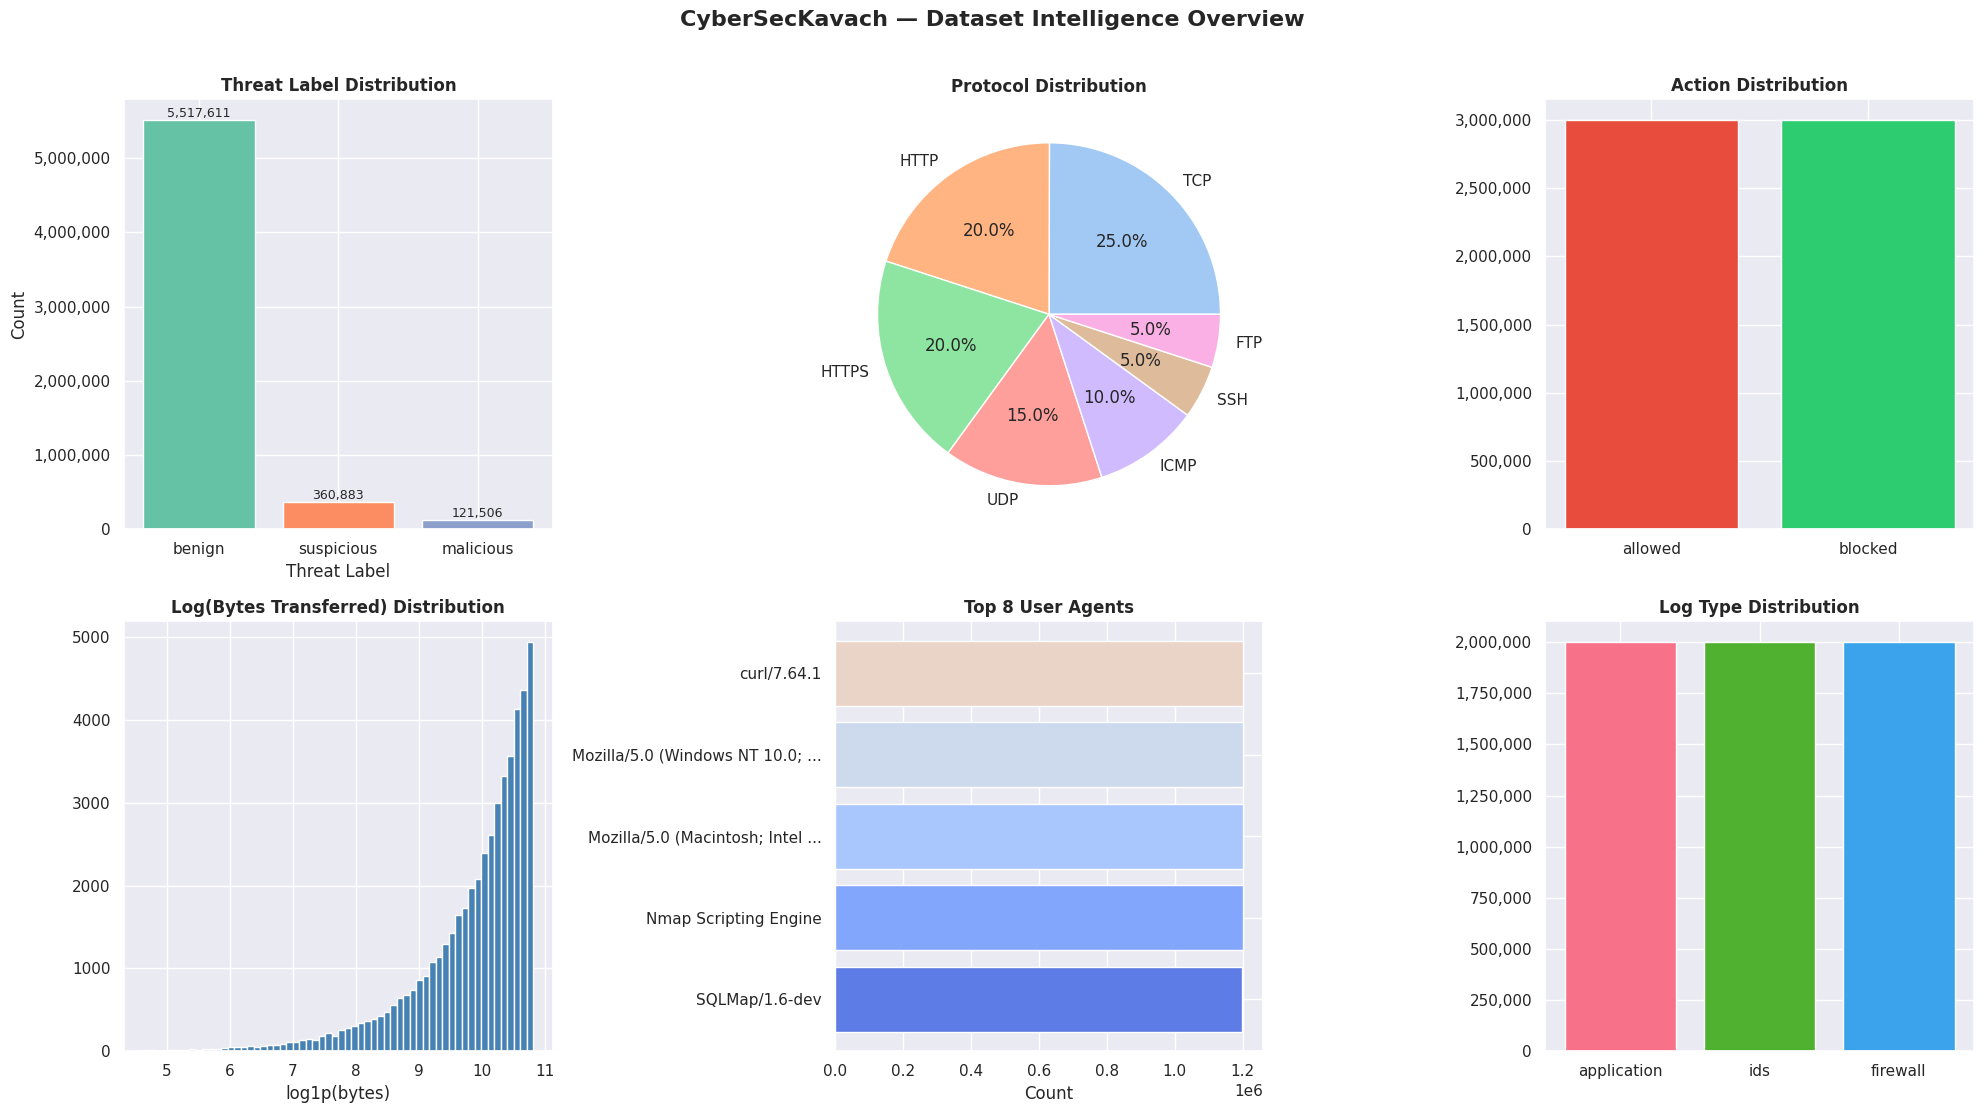

✅ EDA complete. Chart saved → eda_overview.png


In [9]:
# ── 1c. Visualizations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('CyberSecKavach — Dataset Intelligence Overview', fontsize=16, fontweight='bold', y=1.01)

# 1. Threat label
vc = df['threat_label'].value_counts()
axes[0,0].bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
axes[0,0].set_title('Threat Label Distribution', fontweight='bold')
axes[0,0].set_xlabel('Threat Label')
axes[0,0].set_ylabel('Count')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in axes[0,0].patches:
    axes[0,0].annotate(f'{bar.get_height():,.0f}', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                       ha='center', va='bottom', fontsize=9)

# 2. Protocol
vc2 = df['protocol'].value_counts()
axes[0,1].pie(vc2.values, labels=vc2.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel', len(vc2)))
axes[0,1].set_title('Protocol Distribution', fontweight='bold')

# 3. Action
vc3 = df['action'].value_counts()
axes[0,2].bar(vc3.index, vc3.values, color=['#e74c3c', '#2ecc71'])
axes[0,2].set_title('Action Distribution', fontweight='bold')
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 4. Bytes transferred
sample_bytes = df['bytes_transferred'].dropna().sample(50000, random_state=42)
axes[1,0].hist(np.log1p(sample_bytes), bins=60, color='steelblue', edgecolor='white')
axes[1,0].set_title('Log(Bytes Transferred) Distribution', fontweight='bold')
axes[1,0].set_xlabel('log1p(bytes)')

# 5. Top user agents
ua_vc = df['user_agent'].value_counts().head(8)
short_labels = [u[:30]+'...' if len(u) > 30 else u for u in ua_vc.index]
axes[1,1].barh(short_labels[::-1], ua_vc.values[::-1], color=sns.color_palette('coolwarm', 8))
axes[1,1].set_title('Top 8 User Agents', fontweight='bold')
axes[1,1].set_xlabel('Count')

# 6. Log type
vc6 = df['log_type'].value_counts()
axes[1,2].bar(vc6.index, vc6.values, color=sns.color_palette('husl', len(vc6)))
axes[1,2].set_title('Log Type Distribution', fontweight='bold')
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete. Chart saved → eda_overview.png')


In [10]:
# ── 1d. Cross-tab: threat vs action (security insight) ───────────────────────
ct = pd.crosstab(df['threat_label'], df['action'], normalize='index').round(3) * 100
print('Threat label vs Action (% of row):')
print(ct.to_string())

print('\nBytes transferred by threat label:')
print(df.groupby('threat_label')['bytes_transferred']
        .agg(['mean','median','max'])
        .applymap(lambda x: f'{x:,.1f}')
        .to_string())

Threat label vs Action (% of row):
action        allowed  blocked
threat_label                  
benign        50.0000  50.0000
malicious     50.1000  49.9000
suspicious    50.0000  50.0000

Bytes transferred by threat label:
                  mean    median       max
threat_label                              
benign        25,046.7  25,038.0  50,000.0
malicious     25,016.1  24,905.0  50,000.0
suspicious    25,053.0  25,048.0  50,000.0


---
## 🔧 Step 2 — Log Normalization Engine

> **Goal:** Convert heterogeneous raw log rows into canonical, NLP-ready cybersecurity sentences.  
> This is the most critical engineering layer — it enables semantic generalization across log sources.

**Before normalization:**
```
protocol=TCP | action=blocked | user_agent=Nmap Scripting Engine
```
**After normalization:**
```
Blocked TCP firewall request from 192.168.1.125 to 192.168.1.124 using Nmap scanner targeting /admin transferring 10889 bytes.
```
These are now semantically equivalent to MiniLM:
- *blocked TCP request* ≈ *denied TCP connection* ≈ *rejected TCP packet*


In [11]:
# ── 2a. User-agent normalizer ─────────────────────────────────────────────────
UA_PATTERNS = [
    (r'Nmap',              'Nmap network scanner'),
    (r'sqlmap',            'sqlmap SQL injection tool'),
    (r'Nikto',             'Nikto web vulnerability scanner'),
    (r'Masscan',           'Masscan port scanner'),
    (r'ZmEu',              'ZmEu exploit scanner'),
    (r'python-requests',   'Python requests automation script'),
    (r'curl',              'curl command-line client'),
    (r'wget',              'wget download tool'),
    (r'Go-http-client',    'Go HTTP client'),
    (r'Java',              'Java HTTP client'),
    (r'libwww-perl',       'Perl LWP scanner'),
    (r'Mozilla',           None),   # handled separately below
]

def normalize_user_agent(ua: str) -> str:
    """Map verbose UA strings to compact, meaningful tokens."""
    if pd.isna(ua) or str(ua).strip() == '':
        return 'unknown agent'
    ua = str(ua).strip()
    for pattern, label in UA_PATTERNS:
        if re.search(pattern, ua, re.IGNORECASE):
            if label is not None:
                return label
            # Mozilla: extract OS hint
            match = re.search(r'\(([^)]+)\)', ua)
            os_hint = match.group(1).split(';')[0].strip() if match else 'unknown OS'
            return f'browser on {os_hint}'
    return 'other HTTP client'


# ── 2b. Core normalization function ──────────────────────────────────────────
def log_to_text(row) -> str:
    """
    Convert a raw log row (dict or pd.Series) into a canonical
    cybersecurity NLP sentence.

    Example output:
        'Blocked TCP firewall request from 192.168.1.125 to 192.168.1.124
         using Nmap network scanner targeting /admin transferring 10889 bytes.'
    """
    action   = str(row.get('action',   'unknown')).lower().strip()
    protocol = str(row.get('protocol', 'unknown')).upper().strip()
    log_type = str(row.get('log_type', 'unknown')).lower().strip()
    src_ip   = str(row.get('source_ip', 'unknown'))
    dst_ip   = str(row.get('dest_ip',   'unknown'))
    ua       = normalize_user_agent(row.get('user_agent', ''))
    path     = str(row.get('request_path', '/')).strip()
    bytes_tx = row.get('bytes_transferred', 0)

    try:
        bytes_tx = int(bytes_tx)
    except (ValueError, TypeError):
        bytes_tx = 0

    return (
        f'{action.capitalize()} {protocol} {log_type} request '
        f'from {src_ip} to {dst_ip} '
        f'using {ua} '
        f'targeting {path} '
        f'transferring {bytes_tx} bytes.'
    )


# ── 2c. Validate on sample rows ───────────────────────────────────────────────
print('=== Normalization Examples ===')
for i, (_, row) in enumerate(df.head(5).iterrows()):
    print(f'[{i}] {log_to_text(row)}')
    print(f'     → label: {row["threat_label"]}')
    print()
print('✅ Normalization engine ready.')


=== Normalization Examples ===
[0] Blocked TCP firewall request from 192.168.1.125 to 192.168.1.124 using Nmap network scanner targeting / transferring 10889 bytes.
     → label: benign

[1] Blocked ICMP application request from 192.168.1.201 to 192.168.1.201 using Nmap network scanner targeting / transferring 36522 bytes.
     → label: benign

[2] Allowed HTTP application request from 192.168.1.248 to 192.168.1.15 using browser on Windows NT 10.0 targeting /login transferring 20652 bytes.
     → label: benign

[3] Allowed HTTP application request from 192.168.1.236 to 192.168.1.219 using browser on Macintosh targeting /login transferring 5350 bytes.
     → label: benign

[4] Allowed ICMP application request from 192.168.1.221 to 192.168.1.61 using browser on Windows NT 10.0 targeting / transferring 40691 bytes.
     → label: benign

✅ Normalization engine ready.


---
## 🧹 Step 3 — Data Cleaning & Label Engineering

> **Goal:** Remove noise, standardize categoricals, and encode threat labels for training.

| Threat | Label |
|--------|-------|
| benign | 0 |
| suspicious | 1 |
| malicious | 2 |
| port_scan | 3 |
| brute_force | 4 |
| ddos | 5 |


In [12]:
# ── 3a. Drop nulls & duplicates ──────────────────────────────────────────────
print(f'Before cleaning: {df.shape[0]:,} rows')

df.drop_duplicates(inplace=True)
df.dropna(subset=['threat_label', 'protocol', 'action', 'bytes_transferred'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'After  cleaning: {df.shape[0]:,} rows')
print(f'Removed:         {6_000_000 - df.shape[0]:,} rows')


Before cleaning: 6,000,000 rows
After  cleaning: 6,000,000 rows
Removed:         0 rows


In [13]:
# ── 3b. Standardize categoricals ─────────────────────────────────────────────
df['protocol']     = df['protocol'].str.upper().str.strip()
df['action']       = df['action'].str.lower().str.strip()
df['log_type']     = df['log_type'].str.lower().str.strip()
df['threat_label'] = df['threat_label'].str.lower().str.strip()
df['request_path'] = df['request_path'].fillna('/').str.strip()
df['user_agent']   = df['user_agent'].fillna('unknown')

print('Unique protocols:', sorted(df['protocol'].unique()))
print('Unique actions:  ', sorted(df['action'].unique()))
print('Unique labels:   ', sorted(df['threat_label'].unique()))


Unique protocols: ['FTP', 'HTTP', 'HTTPS', 'ICMP', 'SSH', 'TCP', 'UDP']
Unique actions:   ['allowed', 'blocked']
Unique labels:    ['benign', 'malicious', 'suspicious']


In [14]:
# ── 3c. Label encoding ────────────────────────────────────────────────────────
LABEL_MAP = {
    'benign':      0,
    'suspicious':  1,
    'malicious':   2,
    'port_scan':   3,
    'brute_force': 4,
    'ddos':        5,
}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

df['label'] = df['threat_label'].map(LABEL_MAP)

unmapped = df['label'].isna().sum()
if unmapped > 0:
    print(f'⚠️  Unmapped labels ({unmapped} rows):')
    print(df[df['label'].isna()]['threat_label'].value_counts())
    df.dropna(subset=['label'], inplace=True)

df['label'] = df['label'].astype(int)

print('Label distribution:')
ld = df['label'].value_counts().sort_index()
for idx, cnt in ld.items():
    print(f'  {idx} ({INV_LABEL_MAP[idx]:<12}): {cnt:>10,}  ({cnt/len(df)*100:.2f}%)')

print(f'\n✅ Labels encoded. Final dataset: {df.shape[0]:,} rows')


Label distribution:
  0 (benign      ):  5,517,611  (91.96%)
  1 (suspicious  ):    360,883  (6.01%)
  2 (malicious   ):    121,506  (2.03%)

✅ Labels encoded. Final dataset: 6,000,000 rows


---
## ⚙️ Step 4 — Structured Feature Engineering

> **Goal:** Add numeric security signals that complement MiniLM embeddings.  
> Transformers alone are insufficient — structured signals like byte volume, timing, and tool entropy are powerful discriminators.

| Feature | Rationale |
|---------|----------|
| `hour` | Attacks spike at off-hours |
| `day_of_week` | Weekend traffic is anomalous in enterprise |
| `bytes_log` | DDoS = high volume; recon = low volume |
| `path_depth` | Deep paths = targeted attacks |
| `ua_entropy` | High entropy → automated/scanner tools |
| `same_ip` | Loopback-style scanning indicator |
| `is_blocked` | Action signal |


In [15]:
# ── 4a. Timestamp features ───────────────────────────────────────────────────
df['timestamp']   = pd.to_datetime(df['timestamp'], errors='coerce')
df['hour']        = df['timestamp'].dt.hour.fillna(0).astype(int)
df['day_of_week'] = df['timestamp'].dt.dayofweek.fillna(0).astype(int)

# ── 4b. Path features ────────────────────────────────────────────────────────
df['path_depth'] = df['request_path'].apply(
    lambda p: len(str(p).strip('/').split('/')) if pd.notna(p) else 0
)

# ── 4c. IP features ──────────────────────────────────────────────────────────
df['same_ip'] = (df['source_ip'] == df['dest_ip']).astype(int)

# ── 4d. User-agent entropy ───────────────────────────────────────────────────
def ua_entropy(ua: str) -> float:
    if pd.isna(ua) or len(str(ua)) == 0:
        return 0.0
    ua = str(ua)
    probs = [ua.count(c) / len(ua) for c in set(ua)]
    return float(scipy_entropy(probs))

df['ua_entropy'] = df['user_agent'].apply(ua_entropy)

# ── 4e. Byte volume ───────────────────────────────────────────────────────────
df['bytes_log'] = np.log1p(df['bytes_transferred'].fillna(0))

# ── 4f. Action binary ─────────────────────────────────────────────────────────
df['is_blocked'] = (df['action'] == 'blocked').astype(int)

# ── 4g. Protocol one-hot ──────────────────────────────────────────────────────
proto_dummies = pd.get_dummies(df['protocol'], prefix='proto').astype(int)
df = pd.concat([df, proto_dummies], axis=1)

STRUCTURED_COLS = (
    ['hour', 'day_of_week', 'path_depth', 'same_ip',
     'ua_entropy', 'bytes_log', 'is_blocked']
    + [c for c in df.columns if c.startswith('proto_')]
)

print(f'Structured features ({len(STRUCTURED_COLS)}): {STRUCTURED_COLS}')
print(df[STRUCTURED_COLS].describe().round(3).to_string())
print('\n✅ Feature engineering complete.')


Structured features (14): ['hour', 'day_of_week', 'path_depth', 'same_ip', 'ua_entropy', 'bytes_log', 'is_blocked', 'proto_FTP', 'proto_HTTP', 'proto_HTTPS', 'proto_ICMP', 'proto_SSH', 'proto_TCP', 'proto_UDP']
              hour  day_of_week   path_depth      same_ip   ua_entropy    bytes_log   is_blocked    proto_FTP   proto_HTTP  proto_HTTPS   proto_ICMP    proto_SSH    proto_TCP    proto_UDP
count 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000 6000000.0000
mean        0.0000       2.9920       1.1980       0.0030       2.9030       9.8320       0.5000       0.0500       0.2000       0.2000       0.1000       0.0500       0.2500       0.1500
std         0.0000       2.0040       0.5000       0.0530       0.5300       0.9600       0.5000       0.2180       0.4000       0.4000       0.3000       0.2180       0.4330       0.3570
min         0.0000       0.0000      

---
## 🧠 Step 5 — Tokenization & Embedding Pipeline

> **Model:** `sentence-transformers/all-MiniLM-L6-v2`  
> **Why MiniLM?** Fast (5-10ms/batch), lightweight (80MB), strong semantic quality — ideal for Kaggle + HuggingFace deployment.

> ⚠️ **Note on scale:** 6M rows × embedding is GPU-hours of work. We train on a **200K stratified sample** — statistically representative and Colab/Kaggle safe. For production batch inference, use the ONNX pipeline from Step 9.


In [16]:
# ── 5a. Load MiniLM ───────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

print('Loading MiniLM-L6-v2...')
t0 = time.time()
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(f'✅ Model loaded in {time.time()-t0:.1f}s')

# Sanity check — semantic similarity test
test_sentences = [
    'blocked TCP request using Nmap scanner',
    'denied TCP connection using Nmap scanner',
    'allowed HTTP request using browser on Windows',
]
test_embs = embedder.encode(test_sentences, normalize_embeddings=True)
sim_12 = float(np.dot(test_embs[0], test_embs[1]))
sim_13 = float(np.dot(test_embs[0], test_embs[2]))
print(f'\nSemantic similarity check:')
print(f'  blocked ≈ denied (same threat): {sim_12:.3f}  ← should be HIGH')
print(f'  blocked ≈ benign browser:       {sim_13:.3f}  ← should be LOW')


Loading MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded in 3.8s

Semantic similarity check:
  blocked ≈ denied (same threat): 0.864  ← should be HIGH
  blocked ≈ benign browser:       0.322  ← should be LOW


In [18]:
# ── 5b. Stratified training sample ───────────────────────────────────────────
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 200_000

# Stratified sample to preserve class ratios
train_df, _ = train_test_split(
    df,
    train_size=min(TRAIN_SIZE, len(df)),
    stratify=df['label'],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)

print(f'Training sample: {len(train_df):,} rows')
print('Label distribution in sample:')
for lbl, cnt in train_df['label'].value_counts().sort_index().items():
    print(f'  {lbl} ({INV_LABEL_MAP[lbl]:<12}): {cnt:>8,}')


Training sample: 200,000 rows
Label distribution in sample:
  0 (benign      ):  183,920
  1 (suspicious  ):   12,030
  2 (malicious   ):    4,050


In [19]:
from tqdm.auto import tqdm
tqdm.pandas()

# ── 5c. Generate log text + embed ────────────────────────────────────────────
print('Normalizing log text...')
t0 = time.time()

# Progress bar for apply
train_df['log_text'] = train_df.progress_apply(log_to_text, axis=1)

print(f'  Done in {time.time()-t0:.1f}s')

print('Encoding with MiniLM (batched)...')
t0 = time.time()

# SentenceTransformer already supports progress bar
embeddings = embedder.encode(
    train_df['log_text'].tolist(),
    batch_size=512,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print(f'  Done in {time.time()-t0:.1f}s')
print(f'  Embedding shape: {embeddings.shape}  (N × 384-dim)')
print('✅ Embeddings ready.')

Normalizing log text...


  0%|          | 0/200000 [00:00<?, ?it/s]

  Done in 6.2s
Encoding with MiniLM (batched)...


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

  Done in 80.5s
  Embedding shape: (200000, 384)  (N × 384-dim)
✅ Embeddings ready.


---
## 🎯 Step 6 — Train Threat Classification Model

> **Architecture:** MiniLM embeddings (384-dim) + structured features → Logistic Regression (strong, fast, interpretable baseline)

> **Cybersecurity metric priority:**
> - F1-score (primary) — balance precision and recall
> - Recall (high priority) — missing attacks is dangerous
> - Precision (secondary) — false positives waste analyst time


In [20]:
# ── 6a. Build feature matrix ─────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

struct_matrix = train_df[STRUCTURED_COLS].fillna(0).values.astype(np.float32)

scaler = StandardScaler()
struct_scaled = scaler.fit_transform(struct_matrix)

EMBED_DIM = embeddings.shape[1]  # 384
X = np.hstack([embeddings, struct_scaled]).astype(np.float32)
y = train_df['label'].values

print(f'Feature matrix: {X.shape}  ({EMBED_DIM} MiniLM + {len(STRUCTURED_COLS)} structured)')


Feature matrix: (200000, 398)  (384 MiniLM + 14 structured)


In [21]:
# ── 6b. Train / validation split ─────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}')


Train: 170,000  |  Val: 30,000


In [23]:
# ── 6c. Train Logistic Regression ───────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

print('Training Logistic Regression...')
t0 = time.time()

clf = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    n_jobs=-1,
    verbose=1,              # <-- shows training progress
    random_state=RANDOM_STATE,
)

clf.fit(X_train, y_train)

print(f'\n✅ Trained in {time.time()-t0:.1f}s')

# ── Model Info ───────────────────────────────────────────────────────────────
print("\nModel Summary")
print("-" * 50)
print("Classes:", clf.classes_)
print("Number of classes:", len(clf.classes_))
print("Coefficient shape:", clf.coef_.shape)
print("Intercept shape:", clf.intercept_.shape)
print("Iterations used:", clf.n_iter_)

Training Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.



✅ Trained in 42.5s

Model Summary
--------------------------------------------------
Classes: [0 1 2]
Number of classes: 3
Coefficient shape: (3, 398)
Intercept shape: (3,)
Iterations used: [167]


                VALIDATION REPORT

Accuracy: 0.9993

Classification Report:

              precision    recall  f1-score   support

      benign     1.0000    0.9993    0.9996     27588
  suspicious     0.9945    1.0000    0.9972      1805
   malicious     0.9821    0.9967    0.9894       607

    accuracy                         0.9993     30000
   macro avg     0.9922    0.9987    0.9954     30000
weighted avg     0.9993    0.9993    0.9993     30000

Macro F1 Score: 0.9954
ROC-AUC Score: 1.0000


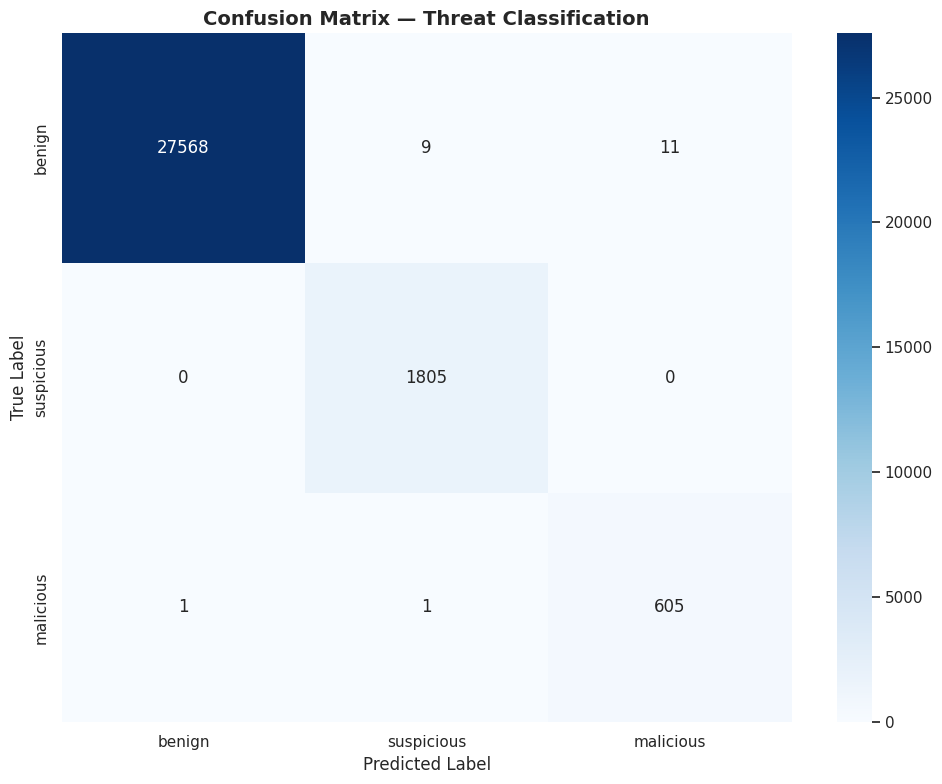


✅ Evaluation complete.


In [25]:
# ── 6d. Evaluation ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred  = clf.predict(X_val)
y_proba = clf.predict_proba(X_val)

# Only labels actually present in validation/prediction
labels_present = sorted(np.unique(np.concatenate([y_val, y_pred])))

# Human-readable class names
target_names_present = [INV_LABEL_MAP[i] for i in labels_present]

print('=' * 60)
print('                VALIDATION REPORT')
print('=' * 60)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f'\nAccuracy: {acc:.4f}')

# Classification report
print('\nClassification Report:\n')

print(
    classification_report(
        y_val,
        y_pred,
        labels=labels_present,
        target_names=target_names_present,
        digits=4
    )
)

# Macro F1
macro_f1 = f1_score(y_val, y_pred, average='macro')
print(f'Macro F1 Score: {macro_f1:.4f}')

# ROC-AUC
try:
    auc = roc_auc_score(
        y_val,
        y_proba,
        multi_class='ovr',
        average='macro'
    )
    print(f'ROC-AUC Score: {auc:.4f}')

except Exception as e:
    print(f'ROC-AUC skipped: {e}')

# ── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred, labels=labels_present)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names_present,
    yticklabels=target_names_present
)

plt.title(
    'Confusion Matrix — Threat Classification',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

# Save image
plt.savefig(
    'confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('\n✅ Evaluation complete.')

In [26]:
# ── 6e. Save model artifacts ─────────────────────────────────────────────────
import joblib

joblib.dump(clf,    'threat_classifier.pkl')
joblib.dump(scaler, 'struct_scaler.pkl')

print('Saved: threat_classifier.pkl')
print('Saved: struct_scaler.pkl')
print('✅ Model artifacts saved.')


Saved: threat_classifier.pkl
Saved: struct_scaler.pkl
✅ Model artifacts saved.


In [27]:
# ── 7a. Severity rules (SOC-aligned) ─────────────────────────────────────────
# Structure: label → ordered list of (severity, min_confidence)
# First matching threshold wins.
SEVERITY_RULES = {
    'ddos':        [('Critical', 0.90), ('High', 0.70), ('Medium', 0.50), ('Low', 0.0)],
    'brute_force': [('Critical', 0.92), ('High', 0.75), ('Medium', 0.55), ('Low', 0.0)],
    'malicious':   [('Critical', 0.90), ('High', 0.70), ('Medium', 0.50), ('Low', 0.0)],
    'port_scan':   [('High',     0.85), ('Medium', 0.60), ('Low',  0.0)],
    'suspicious':  [('Medium',   0.70), ('Low',  0.0)],
    'benign':      [('Info',     0.0)],
}

SEVERITY_ORDER = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1, 'Info': 0}


def get_severity(label_name: str, confidence: float) -> str:
    rules = SEVERITY_RULES.get(label_name, [('Low', 0.0)])
    for sev, thresh in rules:
        if confidence >= thresh:
            return sev
    return 'Low'


def classify_with_severity(proba_vector: np.ndarray) -> dict:
    """Full prediction output with severity, confidence, and per-class scores."""
    label_idx  = int(np.argmax(proba_vector))
    confidence = float(proba_vector[label_idx])
    label_name = INV_LABEL_MAP[label_idx]
    severity   = get_severity(label_name, confidence)

    return {
        'threat':     label_name,
        'confidence': round(confidence * 100, 2),
        'severity':   severity,
        'all_scores': {
            INV_LABEL_MAP[i]: round(float(p) * 100, 2)
            for i, p in enumerate(proba_vector)
        },
    }


# ── 7b. Demo on validation samples ───────────────────────────────────────────
print('=== Severity Engine Demo (first 8 val samples) ===')
for i, proba in enumerate(y_proba[:8]):
    result = classify_with_severity(proba)
    true_label = INV_LABEL_MAP[y_val[i]]
    match = '✅' if result['threat'] == true_label else '❌'
    print(f"{match} [{i}] Predicted: {result['threat']:<12} "
          f"Conf: {result['confidence']:>6.2f}%  "
          f"Severity: {result['severity']:<8}  "
          f"True: {true_label}")

print('\n✅ Severity engine ready.')


=== Severity Engine Demo (first 8 val samples) ===
✅ [0] Predicted: benign       Conf:  95.08%  Severity: Info      True: benign
✅ [1] Predicted: benign       Conf:  99.52%  Severity: Info      True: benign
✅ [2] Predicted: benign       Conf:  98.42%  Severity: Info      True: benign
✅ [3] Predicted: benign       Conf:  99.88%  Severity: Info      True: benign
✅ [4] Predicted: benign       Conf:  98.89%  Severity: Info      True: benign
✅ [5] Predicted: benign       Conf:  98.81%  Severity: Info      True: benign
✅ [6] Predicted: benign       Conf:  95.32%  Severity: Info      True: benign
✅ [7] Predicted: benign       Conf:  99.88%  Severity: Info      True: benign

✅ Severity engine ready.


---
## 💡 Step 8 — Explainability Layer (SHAP)

> **Goal:** Make the AI explain *why* it flagged a threat. Explainability is non-negotiable in cybersecurity — analysts must understand what triggered an alert.

> We use **SHAP** (SHapley Additive exPlanations) on structured features since they are directly interpretable (bytes, hour, path depth, etc.).


Preparing SHAP explainer...
Computing SHAP values...
✅ SHAP values computed.


<Figure size 1000x600 with 0 Axes>

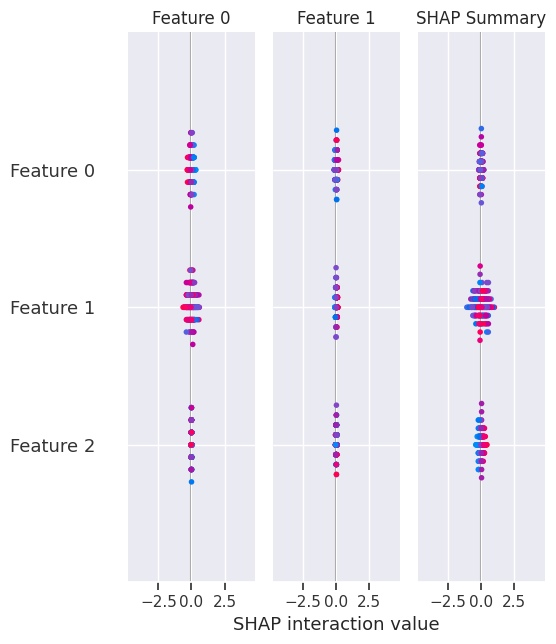


✅ SHAP explainability complete.


In [29]:
# ── 7. SHAP Explainability ──────────────────────────────────────────────────
import shap
import numpy as np
import matplotlib.pyplot as plt

print("Preparing SHAP explainer...")

# Use SAME feature dimensions as training
background = X_train[:200]
sample_data = X_val[:200]

# Create explainer
explainer = shap.LinearExplainer(
    clf,
    background,
    feature_perturbation='interventional'
)

print("Computing SHAP values...")
shap_values = explainer.shap_values(sample_data)

print("✅ SHAP values computed.")

# ── Summary Plot ────────────────────────────────────────────────────────────
class_names = [INV_LABEL_MAP[i] for i in range(len(clf.classes_))]

# Multiclass handling
if isinstance(shap_values, list):

    for i, class_name in enumerate(class_names):

        print(f"\nGenerating SHAP summary for class: {class_name}")

        plt.figure(figsize=(10, 6))

        shap.summary_plot(
            shap_values[i],
            sample_data,
            show=False
        )

        plt.title(f'SHAP Summary — {class_name}')

        plt.tight_layout()

        plt.savefig(
            f'shap_summary_{class_name}.png',
            dpi=150,
            bbox_inches='tight'
        )

        plt.show()

else:
    # Binary/single-output case
    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        sample_data,
        show=False
    )

    plt.title('SHAP Summary')

    plt.tight_layout()

    plt.savefig(
        'shap_summary.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

print("\n✅ SHAP explainability complete.")

In [30]:
print('=== THREAT DISTRIBUTION ===')
print(df['threat_label'].value_counts())
print()
print('=== PROTOCOL DISTRIBUTION ===')
print(df['protocol'].value_counts())
print()
print('=== ACTION DISTRIBUTION ===')
print(df['action'].value_counts())
print()
print('=== NULL VALUES ===')
print(df.isnull().sum())

=== THREAT DISTRIBUTION ===
threat_label
benign        5517611
suspicious     360883
malicious      121506
Name: count, dtype: int64

=== PROTOCOL DISTRIBUTION ===
protocol
TCP      1497493
HTTP     1201528
HTTPS    1199970
UDP       900422
ICMP      599903
SSH       300464
FTP       300220
Name: count, dtype: int64

=== ACTION DISTRIBUTION ===
action
allowed    3000646
blocked    2999354
Name: count, dtype: int64

=== NULL VALUES ===
timestamp            0
source_ip            0
dest_ip              0
protocol             0
action               0
threat_label         0
log_type             0
bytes_transferred    0
user_agent           0
request_path         0
label                0
hour                 0
day_of_week          0
path_depth           0
same_ip              0
ua_entropy           0
bytes_log            0
is_blocked           0
proto_FTP            0
proto_HTTP           0
proto_HTTPS          0
proto_ICMP           0
proto_SSH            0
proto_TCP            0
proto_UDP

In [31]:
class LogNormalizer:
    PROTOCOL_MAP = {
        'TCP': 'TCP connection', 'UDP': 'UDP datagram',
        'HTTP': 'HTTP request', 'HTTPS': 'HTTPS secure request',
        'FTP': 'FTP file transfer', 'SSH': 'SSH session',
        'ICMP': 'ICMP ping', 'DNS': 'DNS query'
    }
    ACTION_MAP = {'allowed': 'permitted', 'blocked': 'blocked', 'denied': 'denied', 'dropped': 'dropped'}
    SCANNER_AGENTS = ['nmap', 'sqlmap', 'nikto', 'masscan', 'zap', 'burp', 'dirbuster', 'gobuster', 'wfuzz']

    @staticmethod
    def detect_scanner(user_agent):
        ua_lower = str(user_agent).lower()
        for scanner in LogNormalizer.SCANNER_AGENTS:
            if scanner in ua_lower:
                return scanner
        return 'standard browser'

    @staticmethod
    def classify_path_risk(path):
        path_lower = str(path).lower()
        if any(x in path_lower for x in ['admin', 'config', 'backup', 'wp-', '.sql', '.env', 'shell']):
            return 'high-risk path'
        if any(x in path_lower for x in ['login', 'auth', 'secure']):
            return 'authentication path'
        if any(x in path_lower for x in ['api', 'upload', 'download']):
            return 'data operation path'
        return 'standard path'

    @staticmethod
    def bytes_category(b):
        b = int(b)
        if b < 1000: return 'minimal data transfer'
        if b < 10000: return 'small data transfer'
        if b < 30000: return 'moderate data transfer'
        return 'large data transfer'

    @classmethod
    def normalize(cls, row):
        protocol = cls.PROTOCOL_MAP.get(row.get('protocol', ''), row.get('protocol', 'unknown'))
        action = cls.ACTION_MAP.get(row.get('action', ''), row.get('action', 'unknown'))
        scanner = cls.detect_scanner(row.get('user_agent', ''))
        path_risk = cls.classify_path_risk(row.get('request_path', '/'))
        bytes_cat = cls.bytes_category(row.get('bytes_transferred', 0))
        log_type = row.get('log_type', 'unknown')
        action_cap = action.capitalize()
        if scanner != 'standard browser':
            return f'{action_cap} {protocol} detected by {log_type} log using {scanner} scanner targeting {path_risk} with {bytes_cat}.'
        return f'{action_cap} {protocol} recorded by {log_type} log accessing {path_risk} with {bytes_cat}.'

test_row = df.iloc[0].to_dict()
print('RAW:', test_row)
print('NORMALIZED:', LogNormalizer.normalize(test_row))

RAW: {'timestamp': Timestamp('2024-05-01 00:00:00'), 'source_ip': '192.168.1.125', 'dest_ip': '192.168.1.124', 'protocol': 'TCP', 'action': 'blocked', 'threat_label': 'benign', 'log_type': 'firewall', 'bytes_transferred': 10889, 'user_agent': 'Nmap Scripting Engine', 'request_path': '/', 'label': 0, 'hour': 0, 'day_of_week': 2, 'path_depth': 1, 'same_ip': 0, 'ua_entropy': 2.5325911608011213, 'bytes_log': 9.295600215927006, 'is_blocked': 1, 'proto_FTP': 0, 'proto_HTTP': 0, 'proto_HTTPS': 0, 'proto_ICMP': 0, 'proto_SSH': 0, 'proto_TCP': 1, 'proto_UDP': 0}
NORMALIZED: Blocked TCP connection detected by firewall log using nmap scanner targeting standard path with moderate data transfer.


In [32]:
print('Normalizing all logs...')
df['normalized_text'] = df.apply(LogNormalizer.normalize, axis=1)
print(f'Normalized {len(df)} logs')
print()
for i, text in enumerate(df['normalized_text'].head(3)):
    print(f'{i+1}. {text}')

Normalizing all logs...
Normalized 6000000 logs

1. Blocked TCP connection detected by firewall log using nmap scanner targeting standard path with moderate data transfer.
2. Blocked ICMP ping detected by application log using nmap scanner targeting standard path with large data transfer.
3. Permitted HTTP request recorded by application log accessing authentication path with moderate data transfer.


In [33]:
print(f'Before: {len(df)} rows')
df = df.dropna(subset=['normalized_text', 'threat_label'])
print(f'After nulls: {len(df)} rows')
df = df.drop_duplicates(subset=['normalized_text', 'source_ip', 'dest_ip'])
print(f'After duplicates: {len(df)} rows')

LABEL_MAP = {'benign': 0, 'suspicious': 1, 'malicious': 2}
df['label'] = df['threat_label'].map(LABEL_MAP)
LABEL_NAMES = ['benign', 'suspicious', 'malicious']

print()
print('Label distribution:')
print(df['label'].value_counts().sort_index())

Before: 6000000 rows
After nulls: 6000000 rows
After duplicates: 5441980 rows

Label distribution:
label
0    4982829
1     347445
2     111706
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f'Train: {len(train_df):,}')
print(f'Test: {len(test_df):,}')
print()
print('Train labels:', train_df['label'].value_counts().sort_index().to_dict())

Train: 4,353,584
Test: 1,088,396

Train labels: {0: 3986263, 1: 277956, 2: 89365}


In [35]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['normalized_text'], truncation=True, max_length=128, padding='max_length')

train_dataset = Dataset.from_pandas(train_df[['normalized_text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['normalized_text', 'label']])

train_dataset = train_dataset.map(tokenize_function, batched=True, batch_size=1000)
test_dataset = test_dataset.map(tokenize_function, batched=True, batch_size=1000)

train_dataset = train_dataset.remove_columns(['normalized_text']).rename_column('label', 'labels')
test_dataset = test_dataset.remove_columns(['normalized_text']).rename_column('label', 'labels')

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f'Train: {len(train_dataset):,}')
print(f'Test: {len(test_dataset):,}')

Map:   0%|          | 0/4353584 [00:00<?, ? examples/s]

Map:   0%|          | 0/1088396 [00:00<?, ? examples/s]

Train: 4,353,584
Test: 1,088,396


In [36]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 3

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, problem_type='single_label_classification'
)
print(f'Model: {MODEL_NAME}')
print(f'Parameters: {model.num_parameters():,}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: sentence-transformers/all-MiniLM-L6-v2
Parameters: 22,714,371


In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir='./thekavach-model',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    logging_steps=100,
    save_total_limit=2,
    report_to='none'
)

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=test_dataset,
    compute_metrics=compute_metrics,processing_class=tokenizer
)

print('Training...')
trainer.train()
print('Done!')

Training...


Epoch,Training Loss,Validation Loss


In [ ]:
results = trainer.evaluate()
print('=== RESULTS ===')
for k, v in results.items():
    print(f'{k}: {v:.4f}')

In [ ]:
import os
os.makedirs('models/cyber-threat-model', exist_ok=True)

trainer.save_model('models/cyber-threat-model')
tokenizer.save_pretrained('models/cyber-threat-model')
print('Model saved to models/cyber-threat-model/')

In [ ]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model='models/cyber-threat-model',
    tokenizer='models/cyber-threat-model',
    return_all_scores=True
)

test_texts = [
    'Blocked TCP connection detected by firewall log using nmap scanner targeting high-risk path.',
    'Permitted HTTP request recorded by application log accessing standard path.',
    'Blocked HTTPS secure request detected by ids log using sqlmap scanner targeting authentication path.'
]

for text in test_texts:
    scores = classifier(text)[0]
    scores_dict = {s['label'].replace('LABEL_', ''): s['score'] for s in scores}
    threat = max(scores_dict, key=scores_dict.get)
    confidence = scores_dict[threat]
    print(f'Threat: {threat} | Confidence: {confidence*100:.1f}%')
    print(f'  {text[:80]}...')
    print()

In [ ]:
from huggingface_hub import HfApi, login
import json

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")


# Login - get token from https://huggingface.co/settings/tokens
login(token=secret_value_0)

model_card = '''---
language: en
license: mit
tags:
  - cybersecurity
  - threat-detection
  - text-classification
  - security
  - nlp
  - minilm
pipeline_tag: text-classification
---

# TheKavach - AI Cybersecurity Threat Intelligence Model

A semantic cybersecurity threat detection model built on MiniLM (all-MiniLM-L6-v2).
Trained on 6 million cybersecurity log entries.

## Usage
`python
from transformers import pipeline
classifier = pipeline('text-classification', model='OMCHOKSI108/TheKavach')
result = classifier('Blocked TCP connection detected using nmap scanner.')
`

## Architecture
- Base: sentence-transformers/all-MiniLM-L6-v2
- Parameters: ~22M
- Classes: benign, suspicious, malicious
- Max tokens: 128
'''

with open('models/cyber-threat-model/README.md', 'w') as f:
    f.write(model_card)

config = {
    'model_name': MODEL_NAME,
    'num_labels': 3,
    'label_names': ['benign', 'suspicious', 'malicious'],
    'label_map': {'benign': 0, 'suspicious': 1, 'malicious': 2},
    'max_length': 128,
    'version': '1.0.0',
    'hf_repo': 'OMCHOKSI108/TheKavach'
}
with open('models/cyber-threat-model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Model card and config saved')
print('Run next cell to upload')

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# Create repo (run once)
api.create_repo(repo_id='OMCHOKSI108/TheKavach', repo_type='model', exist_ok=True)

# Upload
api.upload_folder(
    folder_path='models/cyber-threat-model',
    repo_id='OMCHOKSI108/TheKavach',
    repo_type='model'
)

print('Model uploaded to https://huggingface.co/OMCHOKSI108/TheKavach')

In [ ]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model='OMCHOKSI108/TheKavach',
    tokenizer='OMCHOKSI108/TheKavach',
    return_all_scores=True
)

result = classifier('Blocked TCP connection detected by firewall log using nmap scanner targeting high-risk path.')
print('Remote model working!')
for s in result[0]:
    print(f"  {s['label']}: {s['score']*100:.1f}%")